# Prepare Data for Machine Learning Modeling

## Import Libraries

In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Import Preprocessed Data 

In [11]:
ml_data = pd.read_csv("output/processed_variants_for_EDA.tsv", sep="\t", low_memory=False) 
print(f"Loaded {len(ml_data)} variants.")
display(ml_data.head())

Loaded 1906 variants.


,Hugo_Symbol,Consequence,Variant_Type,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT
0,MAPK1,missense_variant,SNP,0.000000,False,1.000,0.01,False,True,1,False,0,Likely Neutral,0,0
1,BRCA1,missense_variant,SNP,0.000000,False,0.344,0.00,False,False,0,False,0,Oncogenic,0,0
2,BRCA1,missense_variant,SNP,0.000032,True,0.026,0.00,False,True,1,False,0,Oncogenic,0,0
3,TP53,missense_variant,SNP,0.000000,False,0.396,0.12,True,True,1,True,2,Oncogenic,0,0
4,TP53,missense_variant,SNP,0.000000,False,0.838,0.02,True,True,1,True,1,Oncogenic,0,0


## Drop Hugo_Symbol Column 

In [12]:
ml_data = ml_data.drop('Hugo_Symbol', axis=1)
display(ml_data.head())

,Consequence,Variant_Type,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT
0,missense_variant,SNP,0.000000,False,1.000,0.01,False,True,1,False,0,Likely Neutral,0,0
1,missense_variant,SNP,0.000000,False,0.344,0.00,False,False,0,False,0,Oncogenic,0,0
2,missense_variant,SNP,0.000032,True,0.026,0.00,False,True,1,False,0,Oncogenic,0,0
3,missense_variant,SNP,0.000000,False,0.396,0.12,True,True,1,True,2,Oncogenic,0,0
4,missense_variant,SNP,0.000000,False,0.838,0.02,True,True,1,True,1,Oncogenic,0,0


## Log-Transform gnomAD_AF

### Visualize before transformation 

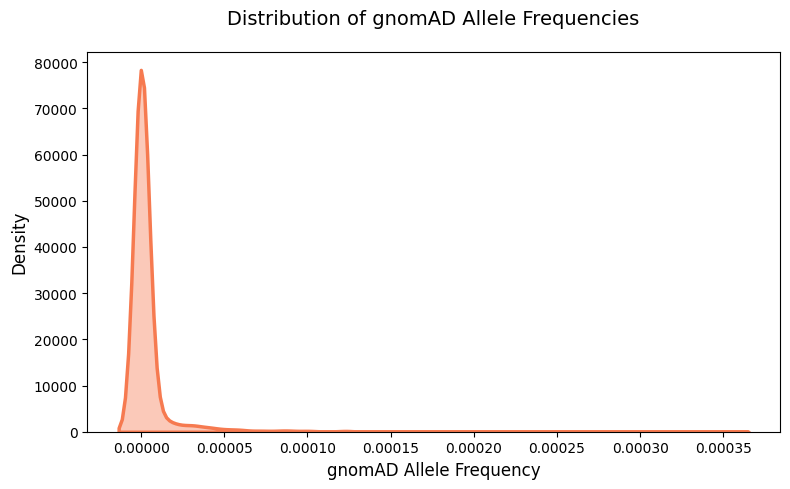

In [13]:
plt.figure(figsize=(8,5)) 

sns.kdeplot(x='gnomAD_AF', 
            data=ml_data,
            color="#f67a50",
            fill=True, 
            common_norm=False,
            alpha=0.4,
            linewidth=2.5)

plt.title('Distribution of gnomAD Allele Frequencies', fontsize=14, pad=20)
plt.xlabel('gnomAD Allele Frequency', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()

plt.show()


### Transform data

In [14]:
epsilon = 1e-6
ml_data['gnomAD_AF_log'] = np.log10(ml_data['gnomAD_AF'] + epsilon)

### Visualize after transformation 

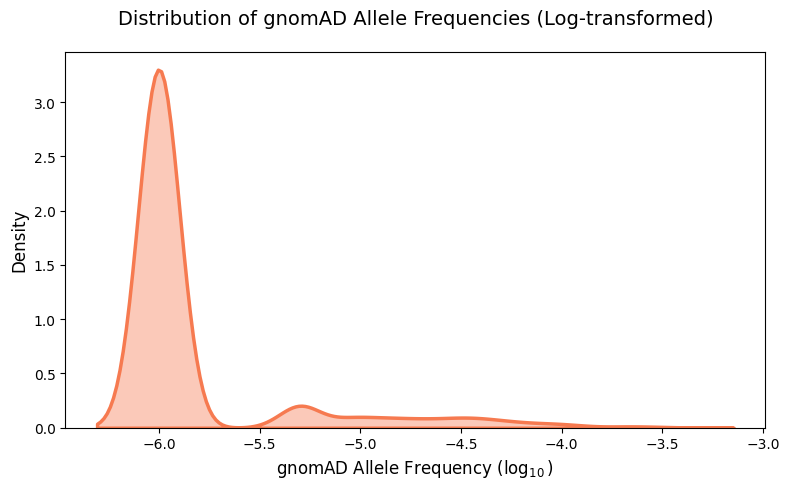

In [15]:
plt.figure(figsize=(8,5)) 

sns.kdeplot(x='gnomAD_AF_log', 
            data=ml_data,
            color="#f67a50",
            fill=True, 
            common_norm=False,
            alpha=0.4,
            linewidth=2.5)

plt.title('Distribution of gnomAD Allele Frequencies (Log-transformed)', fontsize=14, pad=20)
plt.xlabel(r'gnomAD Allele Frequency ($\log_{10}$)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()

plt.show()


### Drop gnomAD_AF Column

In [16]:
ml_data = ml_data.drop('gnomAD_AF', axis=1)
display(ml_data.head())

,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT,gnomAD_AF_log
0,missense_variant,SNP,False,1.000,0.01,False,True,1,False,0,Likely Neutral,0,0,-6.000000
1,missense_variant,SNP,False,0.344,0.00,False,False,0,False,0,Oncogenic,0,0,-6.000000
2,missense_variant,SNP,True,0.026,0.00,False,True,1,False,0,Oncogenic,0,0,-4.482754
3,missense_variant,SNP,False,0.396,0.12,True,True,1,True,2,Oncogenic,0,0,-6.000000
4,missense_variant,SNP,False,0.838,0.02,True,True,1,True,1,Oncogenic,0,0,-6.000000


## Map Target to Numbers (1 = "Oncogenic", 0 = "Likely Neutral")

In [17]:
target_map = {'Oncogenic': 1, 'Likely Neutral': 0}
ml_data['TARGET'] = ml_data['ONCOGENIC'].map(target_map)

## Split Data into X (features) and Y (target) 

In [18]:
X = ml_data.drop(['ONCOGENIC', 'TARGET'], axis=1)
y = ml_data['TARGET']

## Split Data into Training and Test

In [19]:
# use stratified sampling for balanced splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Convert Binary Columns to Numeric (0 and 1)

In [20]:
binary_feat = ['has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'IN_FUNC_SITE']

# Convert binary to 0 and 1
for col in binary_feat:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

## One-hot Encoding of Categorical Features

In [21]:
# define columns to encode
multi_cat = ['Consequence', 'Variant_Type']

# OneHotEncoder for columns in 'multi_cat
# drop = 'first' to avoid multicollinearity. 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit to training set and transform both 
train_encoded = encoder.fit_transform(X_train[multi_cat])
test_encoded = encoder.transform(X_test[multi_cat])

# Create dataframe with the encoded names 
encoded_cols = encoder.get_feature_names_out(multi_cat)

X_train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=X_test.index)

# Concatenate data and remove original columns 
X_train = pd.concat([X_train.drop(multi_cat, axis=1), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(multi_cat, axis=1), X_test_encoded_df], axis=1)

display(X_train.head())

,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,...,Consequence_protein_altering_variant,"Consequence_protein_altering_variant,splice_region_variant",Consequence_stop_gained,"Consequence_stop_gained,frameshift_variant","Consequence_stop_gained,splice_region_variant",Variant_Type_DNP,Variant_Type_INS,Variant_Type_ONP,Variant_Type_SNP,Variant_Type_TNP
1497,0,0.908,0.00,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
381,1,0.007,0.08,0,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1055,0,0.087,0.31,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
226,0,0.497,0.01,0,1,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
857,1,0.586,0.01,0,0,0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Identify Outliers Using Z-score

In [22]:
# Detect outliers using z-scores 

# Compute Z-scores
z_scores = (X_train - X_train.mean()) / X_train.std()

# Identify Outliers (absolute Z-score > 3)
outliers = (np.abs(z_scores) > 3)

# Count total outliers
num_outliers = outliers.sum().sum()  # Summing over all columns

print(f"Total number of outliers: {num_outliers}")

Total number of outliers: 365


In [ ]:
# Identify columns with outliers 
outlier_counts = outliers.sum().sort_values(ascending=False)

print("Outliers per feature:")
print(outlier_counts[outlier_counts > 0])

Outliers per feature:
gnomAD_AF_log                                                 54
Variant_Type_INS                                              50
Consequence_missense_variant,splice_region_variant            48
Consequence_protein_altering_variant                          42
SIFT_Score                                                    33
Consequence_inframe_insertion                                 31
Variant_Type_DNP                                              25
Variant_Type_ONP                                              21
Variant_Type_TNP                                              17
Consequence_inframe_deletion,splice_region_variant            13
n_func_sites                                                  13
Consequence_stop_gained                                       13
Consequence_protein_altering_variant,splice_region_variant     2
Consequence_frameshift_variant,splice_region_variant           1
Consequence_stop_gained,frameshift_variant                     1
Con

## Save Processed Dataset for Machine Learning Modeling